In [2]:
import os
import mlflow
import mlflow.tensorflow
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

DATA_DIR = "../data/processed"
MODEL_DIR = "../models"
MODEL_PATH = os.path.join(MODEL_DIR, "cats_dogs_model.h5")

os.makedirs(MODEL_DIR, exist_ok=True)

print("TensorFlow version:", tf.__version__)
print("DATA_DIR:", DATA_DIR)



TensorFlow version: 2.15.0
DATA_DIR: ../data/processed


In [3]:
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
SEED = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "train"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "val"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    os.path.join(DATA_DIR, "test"),
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary",
    shuffle=False
)

print("Class names:", train_ds.class_names)


Found 19998 files belonging to 2 classes.
Found 2500 files belonging to 2 classes.
Found 2500 files belonging to 2 classes.
Class names: ['cats', 'dogs']


In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y)).prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("Augmentation enabled")



Augmentation enabled


In [5]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(224, 224, 3)),
        tf.keras.layers.Rescaling(1./255),

        tf.keras.layers.Conv2D(32, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, 3, activation="relu"),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

model = build_model()
model.summary()



Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 222, 222, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 111, 111, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 109, 109, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 54, 54, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 52, 52, 128)     

In [6]:
mlflow.set_experiment("cats_vs_dogs_mlops")

print("MLflow experiment set")
print("Run MLflow UI using: mlflow ui")


MLflow experiment set
Run MLflow UI using: mlflow ui


In [7]:
EPOCHS = 3

with mlflow.start_run():
    # Log params
    mlflow.log_param("img_size", "224x224")
    mlflow.log_param("batch_size", BATCH_SIZE)
    mlflow.log_param("epochs", EPOCHS)
    mlflow.log_param("optimizer", "adam")
    mlflow.log_param("lr", 1e-4)

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

    # Evaluate
    test_loss, test_acc = model.evaluate(test_ds)

    mlflow.log_metric("test_loss", float(test_loss))
    mlflow.log_metric("test_accuracy", float(test_acc))

    print("Test Accuracy:", test_acc)

    # Save model
    model.save(MODEL_PATH)
    mlflow.log_artifact(MODEL_PATH)

    print("Model saved:", MODEL_PATH)


Epoch 1/3


625/625 [==============================] - 438s 698ms/step - loss: 0.6161 - accuracy: 0.6530 - val_loss: 0.5349 - val_accuracy: 0.7412
Epoch 2/3
625/625 [==============================] - 460s 737ms/step - loss: 0.5381 - accuracy: 0.7284 - val_loss: 0.4897 - val_accuracy: 0.7684
Epoch 3/3
79/79 [==============================] - 17s 214ms/step - loss: 0.4909 - accuracy: 0.7644
Test Accuracy: 0.7644000053405762


c:\Users\kekolamb\Desktop\MLOPS Assignment\MLOPS-Assignment2\cats-dogs-mlops\.venv\Lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


Model saved: ../models\cats_dogs_model.h5


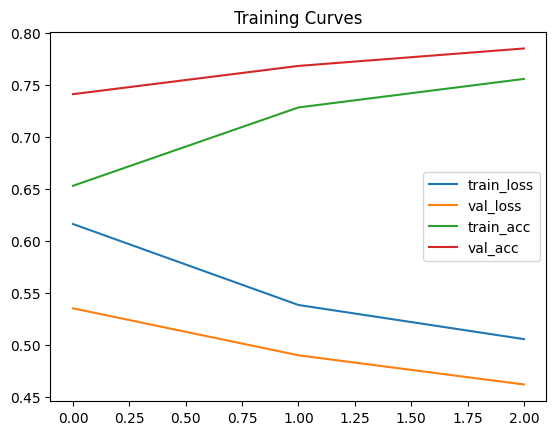

Logged loss/accuracy plot to MLflow


In [8]:
plot_path = "loss_accuracy.png"

plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.title("Training Curves")
plt.legend()
plt.savefig(plot_path)
plt.show()

mlflow.log_artifact(plot_path)
print("Logged loss/accuracy plot to MLflow")


1/1 [==============================] - 0s 500ms/step


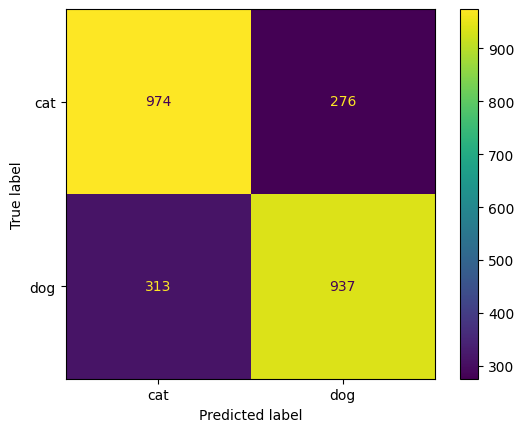

Logged confusion matrix to MLflow


In [9]:
y_true = []
y_pred = []

for x, y in test_ds:
    preds = model.predict(x).flatten()
    y_true.extend(y.numpy().flatten())
    y_pred.extend((preds > 0.5).astype(int))

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(cm, display_labels=["cat", "dog"])
disp.plot()

cm_path = "confusion_matrix.png"
plt.savefig(cm_path)
plt.show()

mlflow.log_artifact(cm_path)
print("Logged confusion matrix to MLflow")
